# DSAC on B747 (ImprovedB747Env)

Minimal example of training Distributional SAC (IQN + CAPS) from HybridRL-FlightControl, implemented in the TensorAeroSpace library and compatible with the normalized `ImprovedB747Env` environment.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from tensoraerospace.agent import DSAC
from tensoraerospace.envs.b747 import ImprovedB747Env

torch.manual_seed(0)
np.random.seed(0)



In [2]:
def make_reference(
    step_count: int,
    step_deg: float = 5.0,
    *,
    dt: float = 0.1,
    step_time_sec: float = 5.0,
) -> np.ndarray:
    """Step reference in radians, shape (1, T)."""
    ref = np.zeros((1, step_count), dtype=np.float32)
    step_idx = int(np.clip(round(step_time_sec / dt), 0, step_count - 1))
    ref[:, step_idx:] = np.deg2rad(step_deg)
    return ref



In [3]:
# Create training / evaluation environments
# NOTE: If the per-step survival bonus is too large, DSAC can learn to "survive" and
# ignore tracking. We'll keep it small and use a completion bonus instead.

USE_VEC_ENV = True

# Time base (match PPO default)
dt = 0.1
tn = 20.0
num_steps = int(tn / dt) + 1

# Evaluation step (fixed)
step_deg_eval = 1.0
ref_eval = make_reference(num_steps, step_deg=step_deg_eval, dt=dt, step_time_sec=5.0)

# Device (cuda / mps / cpu)
if torch.cuda.is_available():
    device = "cuda"
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

# Survival shaping (tune if needed)
SURVIVAL_BONUS = 0.0            # keep 0 or very small so it doesn't dominate tracking
COMPLETION_BONUS = 5.0          # bonus on time-limit finish (not terminated)
EARLY_TERM_PENALTY = 0.0        # extra penalty on termination (in addition to -100)
EARLY_TERM_PER_STEP = 1.0       # extra penalty per remaining step when terminated

if USE_VEC_ENV:
    from tensoraerospace.envs import ImprovedB747VecEnvTorch

    env_train = ImprovedB747VecEnvTorch(
        num_envs=16,
        dt=dt,
        tn=tn,
        initial_state=np.array([0.0, 0.0, 0.0, 0.0], dtype=np.float32),
        device=device,
        seed=0,
        auto_reset=True,
        reward_mode="step_response",
        survival_bonus=SURVIVAL_BONUS,
        completion_bonus=COMPLETION_BONUS,
        early_termination_penalty=EARLY_TERM_PENALTY,
        early_termination_penalty_per_step=EARLY_TERM_PER_STEP,
        step_randomization={
            # Stage 1: learn control on meaningful steps (too small -> agent can ignore)
            "amplitude_deg_range": (1.0, 1.0),
            "min_abs_amplitude_deg": 1.0,
            "step_time_sec_range": (5.0, 5.0),
        },
    )
else:
    # Single env fallback
    step_deg_train = 3.0
    ref_train = make_reference(num_steps, step_deg=step_deg_train, dt=dt, step_time_sec=5.0)
    env_train = ImprovedB747Env(
        initial_state=np.array([0.0, 0.0, 0.0, 0.0], dtype=float),
        reference_signal=ref_train,
        number_time_steps=num_steps,
        dt=dt,
        reward_mode="step_response",
        survival_bonus=SURVIVAL_BONUS,
        completion_bonus=COMPLETION_BONUS,
        early_termination_penalty=EARLY_TERM_PENALTY,
        early_termination_penalty_per_step=EARLY_TERM_PER_STEP,
    )

# Eval env (fixed reference) — keep shaping OFF to measure original metrics
env_eval = ImprovedB747Env(
    initial_state=np.array([0.0, 0.0, 0.0, 0.0], dtype=float),
    reference_signal=ref_eval,
    number_time_steps=num_steps,
    dt=dt,
    reward_mode="step_response",
)

env_train


In [7]:
agent = DSAC(
    env_train,
    # Replay / updates
    batch_size=256,
    memory_capacity=1_000_000,
    learning_starts=50_000,
    updates_per_step=4,
    reward_clip=50.0,  # keep termination signal strong enough
    # Distributional critic
    num_quantiles=32,
    embedding_dim=32,
    hidden_layers=[512, 512],
    huber_threshold=1.0,
    # Optim
    lr=1e-4,
    policy_lr=1e-4,
    max_grad_norm=10.0,
    hidden_size=64,
    # Discount
    gamma=0.995,
    tau=0.005,
    # Exploration / entropy
    alpha=0.2,
    automatic_entropy_tuning=True,
    target_entropy_scale=1.0,
    min_alpha=0.01,
    exploration_noise_std=0.01,
    # CAPS: env already penalizes u/du/ddu -> keep off
    caps_lambda_smoothness=0.0,
    caps_lambda_temporal=0.0,
    caps_noise_std=0.05,
    # Misc
    device=device,
    log_every_updates=200,
    verbose_histogram=False,
    seed=0,
)
agent


In [8]:
# Train
# Curriculum: Stage 1 (±3deg @ 5s), then Stage 2 (±5deg + random step time)
if USE_VEC_ENV:
    print("Stage 1: ±3 deg step at 5s")
    agent.train_vector(
        total_steps=40_000,
        warmup_steps=5_000,
        log_every=1_000,
        reward_window=200,
        save_best=False,
    )

    # Widen curriculum to match eval difficulty
    try:
        env_train.step_rand.amplitude_deg_range = (-5.0, 5.0)
        env_train.step_rand.min_abs_amplitude_deg = 2.0
        env_train.step_rand.step_time_sec_range = (3.0, 7.0)
    except Exception:
        pass

    # Fine-tune: reduce exploration
    agent.exploration_noise_std = 0.0
    agent.target_entropy_scale = 0.7

    print("Stage 2: ±5 deg, random step time")
    agent.train_vector(
        total_steps=80_000,
        warmup_steps=0,
        log_every=1_000,
        reward_window=200,
        save_best=False,
    )
else:
    agent.train(num_episodes=2000, save_best=False)

Stage 1: ±3 deg step at 5s


DSAC train_vector:  63%|██████▎   | 25222/40000 [43:29<25:29,  9.66step/s, mean_R=-11.635, episodes=2015, updates=8e+4, replay=4e+5]     


KeyboardInterrupt: 

Eval return (sum reward): -61.656
Mean reward/step: -0.3098
Max overshoot_ratio: 0.000
Settled: False settle_time_s: -1.0 sign_changes: 0


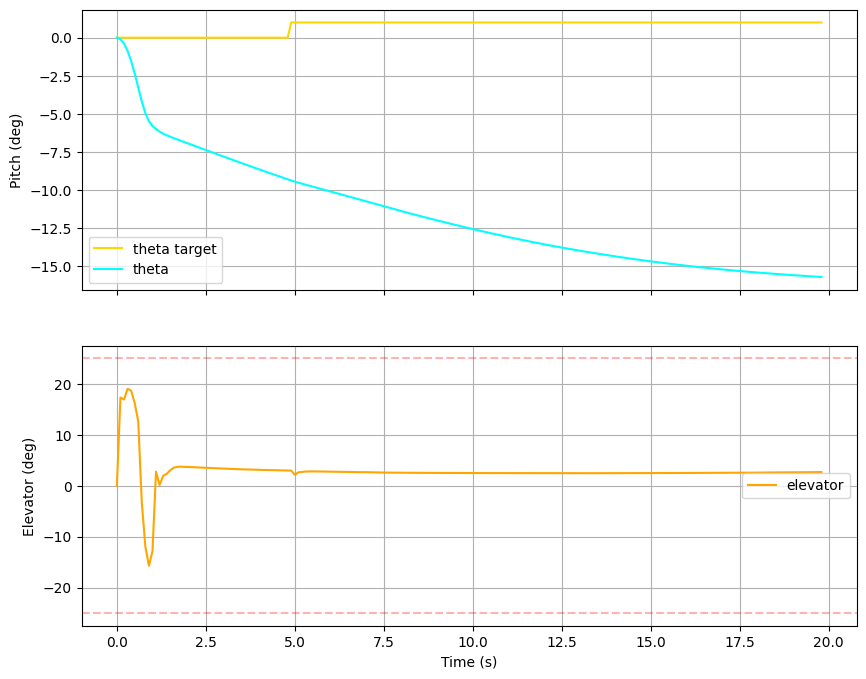

In [6]:
# Evaluate one episode (deterministic policy) and plot transients
# Always evaluate on the *single* env with fixed 5-deg step
obs, _ = env_eval.reset()

theta_deg = []
theta_target_deg = []
elev_deg = []
timestamps = []
rewards = []

# Step-response metrics (from env info)
overshoot_ratio = []
settle_time_s = []
inside_band = []
sign_changes = []

_dt = float(getattr(env_eval, "dt", 0.1))
max_elev = float(getattr(env_eval, "max_stabilizer_angle_deg", 25.0))

terminated = False
truncated = False
step = 0
last_info = {}
while not (terminated or truncated):
    action = agent.select_action(obs, evaluate=True)
    obs, reward, terminated, truncated, info = env_eval.step(action)
    last_info = info

    rewards.append(float(reward))
    theta_deg.append(np.rad2deg(info.get("theta_rad", 0.0)))
    theta_target_deg.append(np.rad2deg(info.get("target_theta_rad", 0.0)))
    elev_deg.append(float(info.get("u_norm", 0.0)) * max_elev)
    timestamps.append(step * _dt)

    overshoot_ratio.append(float(info.get("overshoot_ratio", 0.0)))
    settle_time_s.append(float(info.get("settle_time_s", -1.0)))
    inside_band.append(bool(info.get("inside_band", False)))
    sign_changes.append(int(info.get("sign_changes", 0)))

    step += 1

print(f"Eval return (sum reward): {np.sum(rewards):.3f}")
print(f"Mean reward/step: {float(np.mean(rewards)):.4f}")
print(f"Max overshoot_ratio: {float(np.max(overshoot_ratio)):.3f}")
print(
    "Settled:", bool(last_info.get("settled", False)),
    "settle_time_s:", float(last_info.get("settle_time_s", -1.0)),
    "sign_changes:", int(last_info.get("sign_changes", 0)),
)

theta_deg = np.array(theta_deg)
theta_target_deg = np.array(theta_target_deg)
elev_deg = np.array(elev_deg)
timestamps = np.array(timestamps)

fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax[0].plot(timestamps, theta_target_deg, label="theta target", color="gold")
ax[0].plot(timestamps, theta_deg, label="theta", color="cyan")
ax[0].set_ylabel("Pitch (deg)")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(timestamps, elev_deg, label="elevator", color="orange")
ax[1].axhline(max_elev, color="red", linestyle="--", alpha=0.3)
ax[1].axhline(-max_elev, color="red", linestyle="--", alpha=0.3)
ax[1].set_ylabel("Elevator (deg)")
ax[1].set_xlabel("Time (s)")
ax[1].legend()
ax[1].grid(True)

plt.show()

agent.close()

